## Thesis Chapter 3: Neural underpinnings of DD -- on sciencecloud

1. 'computational space' hypothesis testing with nPRF model params: r2 maps

DAN-patch plots generated in `nets_PFM/npc_net_ana.ipynb`


In [10]:
import os.path as op    
import nibabel as nib
import numpy as np
import pandas as pd

bids_folder = '/mnt_03/ds-dnumrisk'
group_df = pd.read_csv(op.join(bids_folder, 'group_assignment.csv')).set_index('subject')

BIDS_ROOT_LARGE  = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
plot_folder = op.join(BIDS_ROOT_LARGE, 'thesis_materials')

param = 'r2' # 

if param == 'cvr2':
    nPRF_folder = op.join(bids_folder, 'derivatives/encoding_model.cv.denoise')
elif param == 'r2':
    nPRF_folder = op.join(bids_folder, 'derivatives/encoding_model.denoise')

subList = np.arange(1, 67) # 1-66
subList = subList[subList != 3] # remove sub-09
group_df = group_df.loc[subList]


In [11]:
from parietal_patterns.utils.surfaces import get_NPC_mask, get_basic_mask
npc_mask = get_NPC_mask(space='fsaverage5', hemi='both') # (20484,)
npc_mask_L = get_NPC_mask(space='fsaverage5', hemi='L') 
npc_mask_R = get_NPC_mask(space='fsaverage5', hemi='R')

# not needed now
brain_mask, _ = get_basic_mask() # default is fsaverage5, hemi='both' (20484,)
npc_mask_cortex = npc_mask[brain_mask] # 59412
npc_mask_cortex.shape

(18715,)

### Statistics: subjectwise measure - between group comparison

In [12]:
r2_treshold = 0.05
rows = []
for sub in subList:
    nPRFmap_L = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-L.func.gii')).agg_data()
    nPRFmap_R = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii')).agg_data()
    nPRFmap_fsav5 = np.concatenate([nPRFmap_L, nPRFmap_R], axis=0)#[mask]

    nPRF_NPC = nPRFmap_fsav5[npc_mask]
    nPRF_NPC_L = nPRFmap_fsav5[npc_mask_L]
    npRF_NPC_R = nPRFmap_fsav5[npc_mask_R]
    rows.append({'mean_R2': nPRF_NPC.mean(),
                'mean_R2_L': nPRF_NPC_L.mean(),
                'mean_R2_R': npRF_NPC_R.mean(),
                'area(r2>0.01)': (nPRF_NPC > 0.01).sum(),
                'area(r2>0.05)': (nPRF_NPC > 0.05).sum(),
                'area(r2>0.1)': (nPRF_NPC > 0.1).sum(),
                })
                #'area(r2>)': (nPRF_NPC > r2_treshold).sum(),
                #'area(r2>)_L': (nPRF_NPC_L > r2_treshold).sum(),
                #'area(r2>)_R': (npRF_NPC_R > r2_treshold).sum()})

df = pd.DataFrame(rows, index=pd.Index(subList, name='subject')).join(group_df, how='inner').set_index('group', append=True)

In [13]:
from parietal_patterns.utils.statistics import between_group_comparison

for col in df.columns:
    print(f'--- {col} ---')
    stats, stats_terms = between_group_comparison(df, col, group_names = [0,1])
    print(stats_terms)
    print(stats)


--- mean_R2 ---
U(32, 33)
MannwhitneyuResult(statistic=705.0, pvalue=0.020560350397521805)
--- mean_R2_L ---
U(32, 33)
MannwhitneyuResult(statistic=717.0, pvalue=0.013382637341910676)
--- mean_R2_R ---
U(32, 33)
MannwhitneyuResult(statistic=699.0, pvalue=0.025271161776870603)
--- area(r2>0.01) ---
U(32, 33)
MannwhitneyuResult(statistic=720.5, pvalue=0.011755446363074209)
--- area(r2>0.05) ---
U(32, 33)
MannwhitneyuResult(statistic=711.0, pvalue=0.016565573010956416)
--- area(r2>0.1) ---
U(32, 33)
MannwhitneyuResult(statistic=611.5, pvalue=0.1961127395887614)


In [14]:
# correlate with neural precision

BIDS_ROOT = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'

PHENOTYPE_DIR = BIDS_ROOT + '/derivatives/phenotype'

from numrisk.behavior_general.measures_registry import _load_decode_r
nPRF_r = _load_decode_r(dir_=PHENOTYPE_DIR)

In [15]:
nPRF_r

,r
subject,
1,-0.058083
2,0.206071
4,-0.089840
5,-0.023735
6,0.062036
...,...
62,0.305624
63,0.165065
64,0.274937


In [16]:
df_comb = nPRF_r.join(df)
df_comb.corr()['r']

r                1.000000
mean_R2          0.627992
mean_R2_L        0.585550
mean_R2_R        0.600397
area(r2>0.01)    0.509786
area(r2>0.05)    0.604388
area(r2>0.1)     0.411996
Name: r, dtype: float64

### Visualization: group wise averages on brain surface 

In [17]:
hemi = 'R'
rows_DD = []
rows_HC = []

for sub in subList:
    nPRFmap_L = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-L.func.gii')).agg_data()
    nPRFmap_R = nib.load(op.join(nPRF_folder, f'sub-{sub:02d}', 'ses-1', 'func', f'sub-{sub:02d}_ses-1_desc-r2.optim.nilearn_space-fsaverage5_hemi-R.func.gii')).agg_data()
    nPRFmap_fsav5 = np.concatenate([nPRFmap_L, nPRFmap_R], axis=0)#[mask]

    nPRF_NPC = nPRFmap_fsav5[npc_mask]
    
    if group_df.loc[sub, 'group'] == 0:
        rows_HC.append(nPRF_NPC)
    elif group_df.loc[sub, 'group'] == 1:
        rows_DD.append(nPRF_NPC)

df_HC = pd.DataFrame(rows_HC, index=pd.Index(subList, name='subject')[group_df['group'] == 0])
df_DD = pd.DataFrame(rows_DD, index=pd.Index(subList, name='subject')[group_df['group'] == 1])

df_HC.mean(axis=0).shape, df_DD.mean(axis=0).shape

((1510,), (1510,))

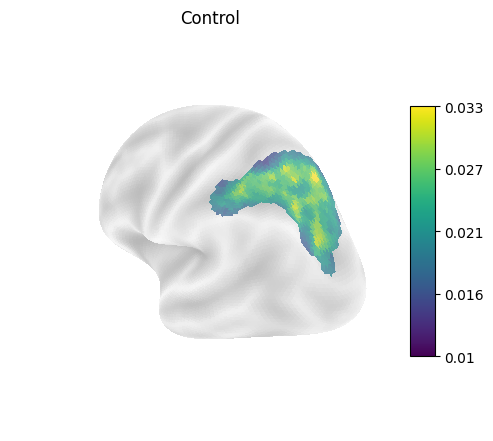

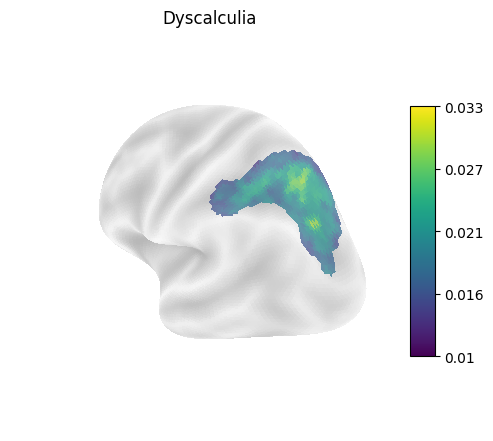

In [21]:
hemi_to_plot = 'L' # 'R'
i_hemi_to_plot = 0 if hemi_to_plot == 'L' else 1  



from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt

cmap = 'viridis' 
# nilearn 0.10+ accepts view=(elev, azim) for arbitrary camera angles, not just
# the 6 named presets ('lateral', 'medial', 'dorsal', 'ventral', 'anterior', 'posterior')
view = (30, 220)  # (elev, azim) in degrees -- tweak freely
vmin = 0.01
vmax = 0.033

fsaverage = fetch_surf_fsaverage('fsaverage5') 
surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

# HC
cortex_map = np.repeat(np.nan, 20484) #np.zeros(20484)
cortex_map[npc_mask] = df_HC.mean(axis=0).values
surf_map_hemi = np.split(cortex_map,2)[i_hemi_to_plot]
nplt.plot_surf(surf_mesh=surf_mesh , surf_map= surf_map_hemi, avg_method = 'median',# infl_right # pial_right
        view= view,cmap=cmap, colorbar=True,title='Control',
        vmin = vmin, vmax=vmax,
        bg_map=bg_map, bg_on_data=True,darkness=0.3) 
plt.show()

# DD
cortex_map = np.repeat(np.nan, 20484) #np.zeros(20484)
cortex_map[npc_mask] = df_DD.mean(axis=0).values
surf_map_hemi = np.split(cortex_map,2)[i_hemi_to_plot]
nplt.plot_surf(surf_mesh=surf_mesh , surf_map= surf_map_hemi, avg_method = 'median',# infl_right # pial_right
        view= view,cmap=cmap, colorbar=True, title='Dyscalculia',
        vmin = vmin, vmax=vmax,
        bg_map=bg_map, bg_on_data=True,darkness=0.3) 
plt.show()

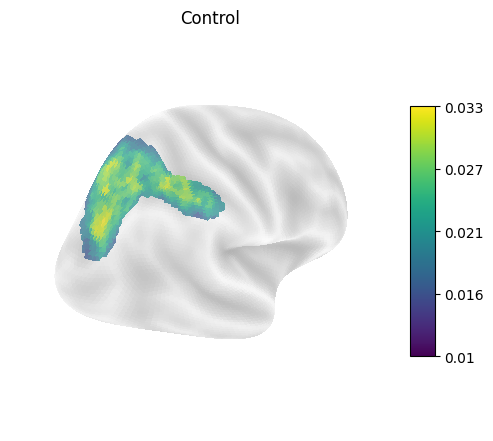

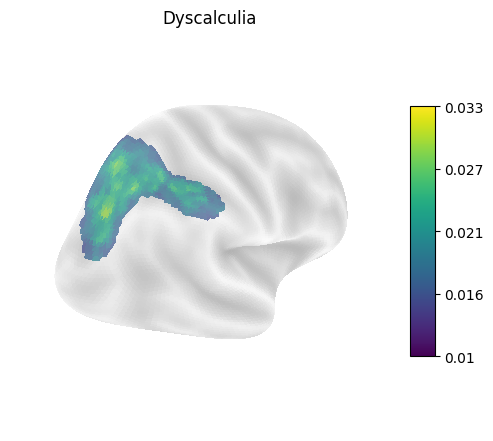

In [ ]:
hemi_to_plot = 'R'
i_hemi_to_plot = 0 if hemi_to_plot == 'L' else 1  



from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt

cmap = 'viridis' 
# nilearn 0.10+ accepts view=(elev, azim) for arbitrary camera angles, not just
# the 6 named presets ('lateral', 'medial', 'dorsal', 'ventral', 'anterior', 'posterior')
view = (30, -30)  # (elev, azim) in degrees -- tweak freely
vmin = 0.01
vmax = 0.033

fsaverage = fetch_surf_fsaverage('fsaverage5') 
surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

# HC
cortex_map = np.repeat(np.nan, 20484) #np.zeros(20484)
cortex_map[npc_mask] = df_HC.mean(axis=0).values
surf_map_hemi = np.split(cortex_map,2)[i_hemi_to_plot]
nplt.plot_surf(surf_mesh=surf_mesh , surf_map= surf_map_hemi, avg_method = 'median',# infl_right # pial_right
        view= view,cmap=cmap, colorbar=True,title='Control',
        vmin = vmin, vmax=vmax,
        bg_map=bg_map, bg_on_data=True,darkness=0.3) 
plt.show()

# DD
cortex_map = np.repeat(np.nan, 20484) #np.zeros(20484)
cortex_map[npc_mask] = df_DD.mean(axis=0).values
surf_map_hemi = np.split(cortex_map,2)[i_hemi_to_plot]
nplt.plot_surf(surf_mesh=surf_mesh , surf_map= surf_map_hemi, avg_method = 'median',# infl_right # pial_right
        view= view,cmap=cmap, colorbar=True, title='Dyscalculia',
        vmin = vmin, vmax=vmax,
        bg_map=bg_map, bg_on_data=True,darkness=0.3) 
plt.show()